In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [5]:
df = pd.read_csv("heart.csv")

print(df.head())
print(df.info())

   age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  slope  \
0   52    1   0       125   212    0        1      168      0      1.0      2   
1   53    1   0       140   203    1        0      155      1      3.1      0   
2   70    1   0       145   174    0        1      125      1      2.6      0   
3   61    1   0       148   203    0        1      161      0      0.0      2   
4   62    0   0       138   294    1        1      106      0      1.9      1   

   ca  thal  target  
0   2     3       0  
1   0     3       0  
2   0     3       0  
3   1     3       0  
4   3     2       0  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 

In [6]:
X = df.drop("target", axis=1)
y = df["target"]

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [8]:
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)
y_pred_dt = dt_model.predict(X_test)
dt_accuracy = accuracy_score(y_test, y_pred_dt)

print("Decision Tree Accuracy:", dt_accuracy)

Decision Tree Accuracy: 0.9853658536585366


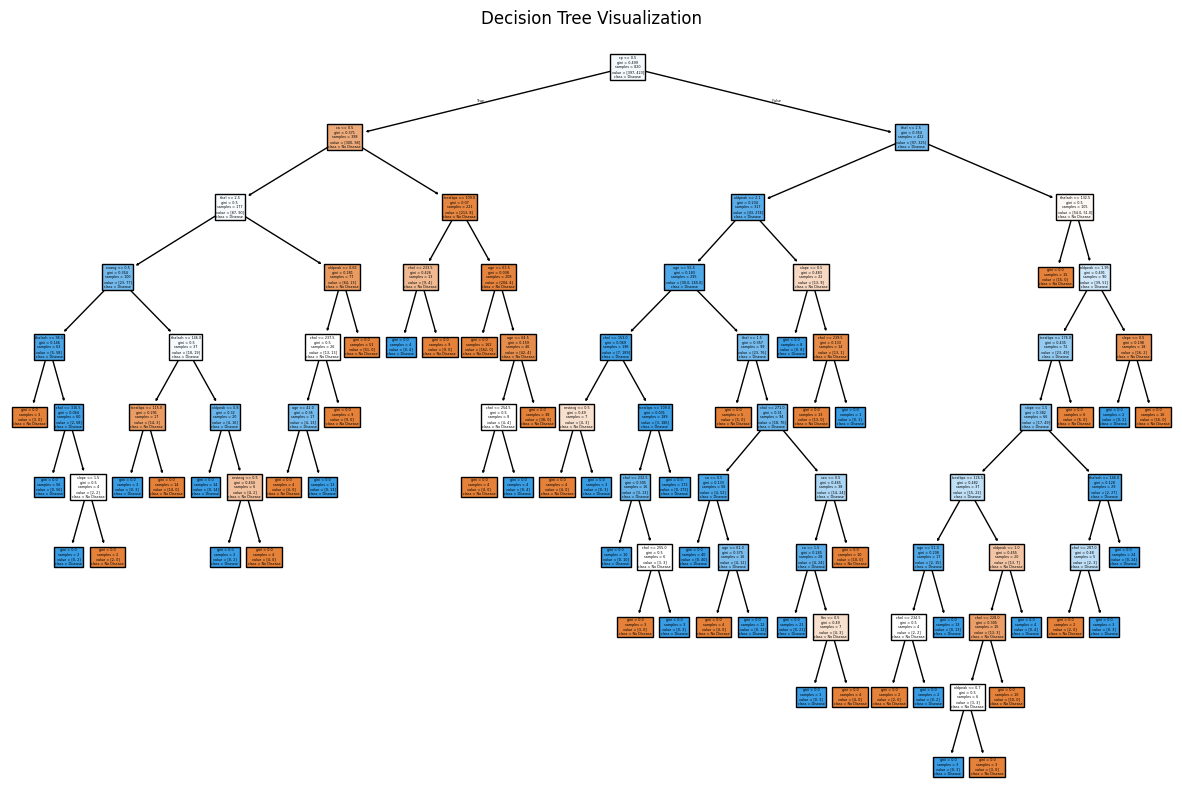

In [10]:
plt.figure(figsize=(15,10))

plot_tree(
    dt_model,
    feature_names=X.columns,
    class_names=["No Disease", "Disease"],
    filled=True
)

plt.title("Decision Tree Visualization")
plt.show()

In [13]:
dt_pruned = DecisionTreeClassifier(
    max_depth=2,
    random_state=40
)
dt_pruned.fit(X_train, y_train)
y_pred_pruned = dt_pruned.predict(X_test)

print("Pruned Decision Tree Accuracy:",
    accuracy_score(y_test, y_pred_pruned)
)

Pruned Decision Tree Accuracy: 0.6780487804878049


In [15]:
rf_model = RandomForestClassifier(
    n_estimators=50,
    random_state=40
)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)
rf_accuracy = accuracy_score(y_test, y_pred_rf)

print("Random Forest Accuracy:", rf_accuracy)

Random Forest Accuracy: 0.9853658536585366


In [16]:
print("Decision Tree Accuracy :", dt_accuracy)
print("Random Forest Accuracy :", rf_accuracy)

Decision Tree Accuracy : 0.9853658536585366
Random Forest Accuracy : 0.9853658536585366


In [17]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
})
importance = importance.sort_values(
    by="Importance",
    ascending=False
)
print(importance)

     Feature  Importance
2         cp    0.135755
12      thal    0.128103
11        ca    0.125704
9    oldpeak    0.119889
7    thalach    0.116022
0        age    0.082147
3   trestbps    0.073993
4       chol    0.073543
8      exang    0.046696
10     slope    0.044181
1        sex    0.028626
6    restecg    0.016798
5        fbs    0.008544


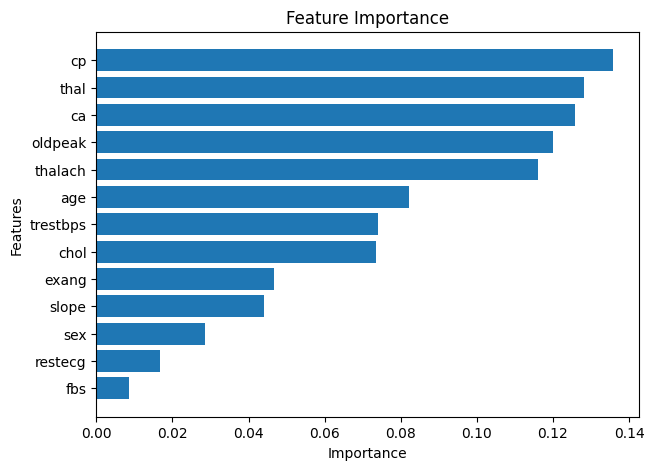

In [19]:
plt.figure(figsize=(7,5))

plt.barh(
    importance["Feature"],
    importance["Importance"]
)
plt.xlabel("Importance")
plt.ylabel("Features")
plt.title("Feature Importance")

plt.gca().invert_yaxis()
plt.show()

In [20]:
cv_scores = cross_val_score(
    rf_model,
    X,
    y,
    cv=5
)
print("Cross Validation Scores:", cv_scores)
print("Average Accuracy:", cv_scores.mean())

Cross Validation Scores: [1.         1.         0.98536585 1.         0.98536585]
Average Accuracy: 0.9941463414634146


In [23]:
print(
    classification_report(
        y_test,
        y_pred_rf
    ))

              precision    recall  f1-score   support

           0       0.97      1.00      0.99       102
           1       1.00      0.97      0.99       103

    accuracy                           0.99       205
   macro avg       0.99      0.99      0.99       205
weighted avg       0.99      0.99      0.99       205



In [24]:
print(confusion_matrix(y_test, y_pred_rf))

[[102   0]
 [  3 100]]
